In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv(r"C:\Users\ayode\OneDrive\Desktop\Sales Forecasting\ElectroTech_Forecasting\data_cleaning\cleaned_data.csv")

In [3]:
data.head()

,Product_ID,Category,Price,Date,Season,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Product_Specification_1,Product_Specification_2,Sales_Volume
0,1103,Laptop,105.32,2009-01-01,Winter,-1.859160,0.546694,84.680465,Spec_C,Long-Battery-Life,49
1,1436,Tablet,145.55,2009-01-01,Winter,-0.345587,0.940428,42.919288,Spec_C,Lightweight,69
2,1271,Smartphone,97.82,2009-01-01,Winter,-0.384738,0.751155,55.191268,Spec_B,Lightweight,50
3,1107,Laptop,64.00,2009-01-01,Winter,0.716763,0.125939,88.746454,Spec_B,High-Resolution,28
4,1072,Tablet,67.83,2009-01-01,Winter,-0.242074,-0.412932,67.947536,Spec_A,Long-Battery-Life,81


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136193 entries, 0 to 136192
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Product_ID                 136193 non-null  int64  
 1   Category                   136193 non-null  object 
 2   Price                      136193 non-null  float64
 3   Date                       136193 non-null  object 
 4   Season                     136193 non-null  object 
 5   Market_Trend_Index         136193 non-null  float64
 6   Competitor_Activity_Score  136193 non-null  float64
 7   Consumer_Confidence_Index  136193 non-null  float64
 8   Product_Specification_1    136193 non-null  object 
 9   Product_Specification_2    136193 non-null  object 
 10  Sales_Volume               136193 non-null  int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 11.4+ MB


In [5]:
laptop_category = data[data['Category'] == 'Laptop']
laptop_category

,Product_ID,Category,Price,Date,Season,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Product_Specification_1,Product_Specification_2,Sales_Volume
0,1103,Laptop,105.32,2009-01-01,Winter,-1.859160,0.546694,84.680465,Spec_C,Long-Battery-Life,49
3,1107,Laptop,64.00,2009-01-01,Winter,0.716763,0.125939,88.746454,Spec_B,High-Resolution,28
5,1021,Laptop,107.02,2009-01-01,Winter,-0.191599,0.913437,84.207215,Spec_B,Long-Battery-Life,39
9,1215,Laptop,52.98,2009-01-01,Winter,-1.188053,-2.649908,76.222631,Spec_B,High-Resolution,42
11,1459,Laptop,73.39,2009-01-01,Winter,-0.065408,-0.035697,48.543606,Spec_C,Long-Battery-Life,58
...,...,...,...,...,...,...,...,...,...,...,...
136162,1340,Laptop,100.75,2020-12-29,Winter,0.704831,0.028397,83.393965,Spec_B,High-Resolution,184
136170,1211,Laptop,168.60,2020-12-29,Winter,-0.929944,1.632201,88.390649,Spec_A,Long-Battery-Life,179
136172,1559,Laptop,109.20,2020-12-29,Winter,-0.769005,-1.091669,79.064827,Spec_B,Long-Battery-Life,136
136178,1688,Laptop,112.29,2020-12-29,Winter,0.219101,1.458811,94.784720,Spec_A,Lightweight,206


In [6]:
data["Date"]=pd.to_datetime(data["Date"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136193 entries, 0 to 136192
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Product_ID                 136193 non-null  int64         
 1   Category                   136193 non-null  object        
 2   Price                      136193 non-null  float64       
 3   Date                       136193 non-null  datetime64[ns]
 4   Season                     136193 non-null  object        
 5   Market_Trend_Index         136193 non-null  float64       
 6   Competitor_Activity_Score  136193 non-null  float64       
 7   Consumer_Confidence_Index  136193 non-null  float64       
 8   Product_Specification_1    136193 non-null  object        
 9   Product_Specification_2    136193 non-null  object        
 10  Sales_Volume               136193 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(4

In [7]:
data.describe()

,Product_ID,Price,Date,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Sales_Volume
count,136193.000000,136193.000000,136193,136193.000000,136193.000000,136193.000000,136193.000000
mean,1347.703384,106.812513,2014-12-22 05:17:20.062264320,-0.000277,-0.000656,70.013109,122.305140
min,1001.000000,40.510000,2009-01-01 00:00:00,-4.067055,-4.181590,40.044830,6.000000
25%,1174.000000,75.560000,2011-12-29 00:00:00,-0.683015,-0.676466,57.521063,81.000000
50%,1348.000000,104.710000,2014-12-19 00:00:00,0.001093,0.000555,70.022715,119.000000
75%,1522.000000,138.310000,2017-11-27 00:00:00,0.680506,0.674953,82.569582,161.000000
max,1694.000000,181.800000,2020-12-30 00:00:00,4.728391,4.661979,99.926291,306.000000
std,200.341518,36.419229,NaN,1.009105,1.001551,14.733722,54.320849


In [8]:
data['YearMonth'] = pd.to_datetime(data['Date']).dt.to_period('M')

In [9]:
data.head()

,Product_ID,Category,Price,Date,Season,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Product_Specification_1,Product_Specification_2,Sales_Volume,YearMonth
0,1103,Laptop,105.32,2009-01-01,Winter,-1.859160,0.546694,84.680465,Spec_C,Long-Battery-Life,49,2009-01
1,1436,Tablet,145.55,2009-01-01,Winter,-0.345587,0.940428,42.919288,Spec_C,Lightweight,69,2009-01
2,1271,Smartphone,97.82,2009-01-01,Winter,-0.384738,0.751155,55.191268,Spec_B,Lightweight,50,2009-01
3,1107,Laptop,64.00,2009-01-01,Winter,0.716763,0.125939,88.746454,Spec_B,High-Resolution,28,2009-01
4,1072,Tablet,67.83,2009-01-01,Winter,-0.242074,-0.412932,67.947536,Spec_A,Long-Battery-Life,81,2009-01


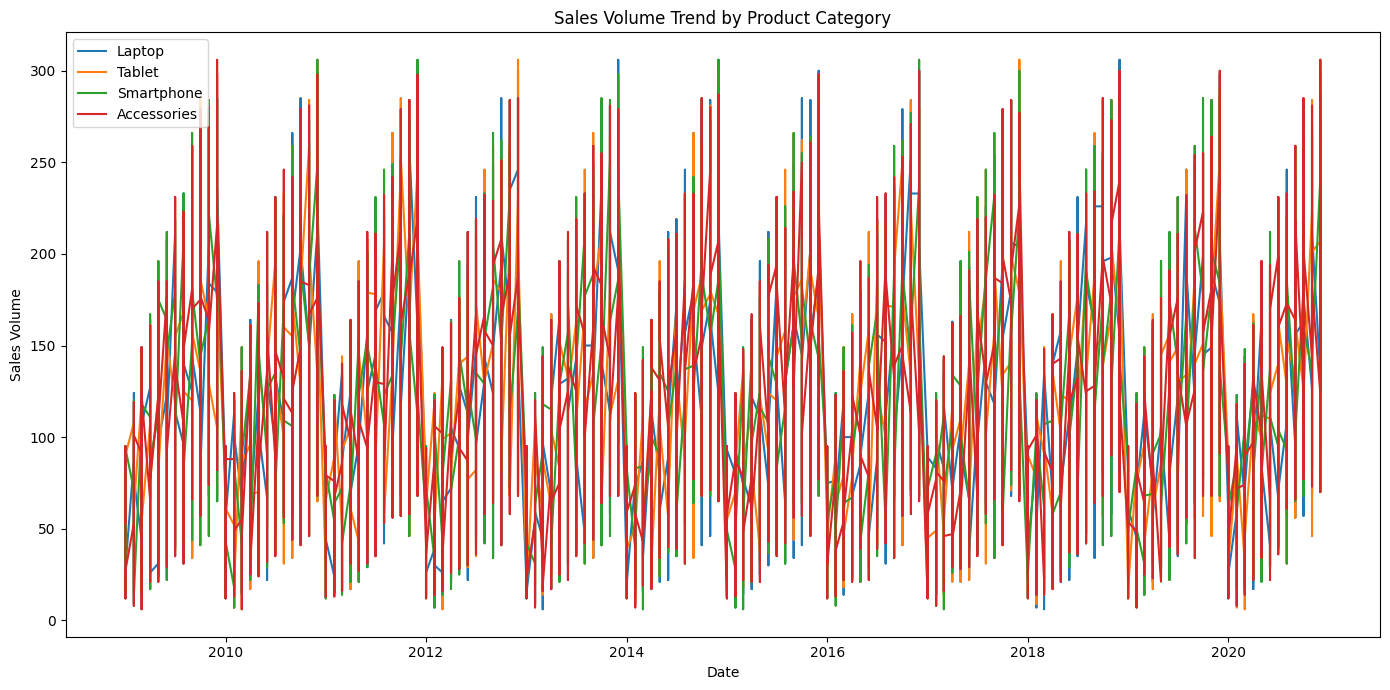

In [10]:

plt.figure(figsize=(14, 7))
for category in data['Category'].unique().tolist():
    subset = data[data['Category'] == category]
    plt.plot((subset['YearMonth']).dt.to_timestamp(), subset['Sales_Volume'], label=category)

plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.title('Sales Volume Trend by Product Category')
plt.legend()
plt.tight_layout()
plt.show()

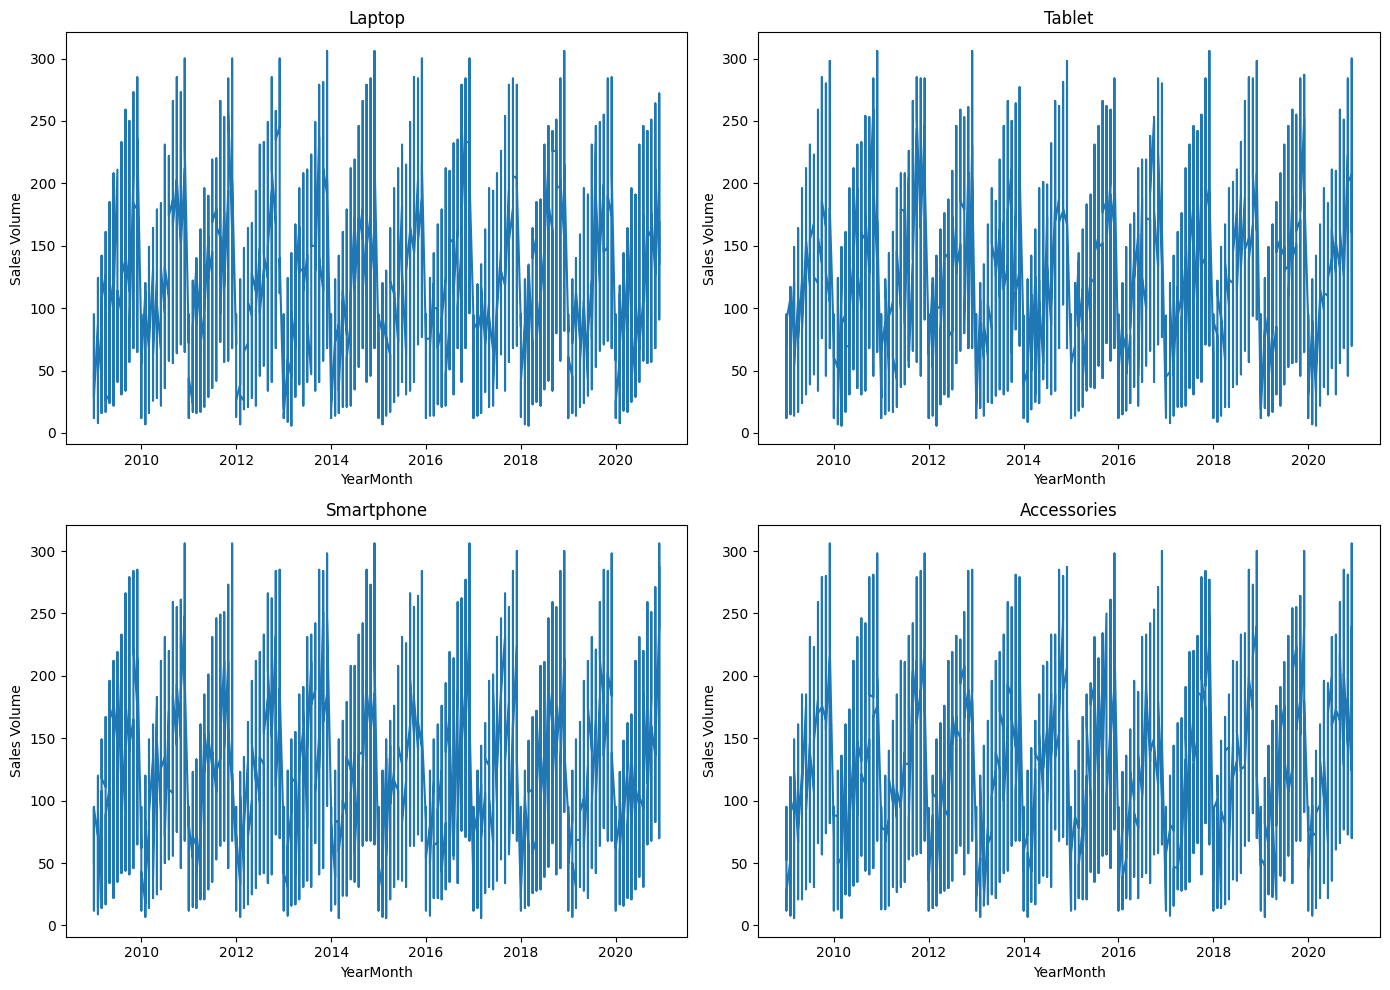

In [11]:
# Select exactly four categories
categories = data['Category'].unique().tolist()

plt.figure(figsize=(14, 10))

for i, category in enumerate(categories):
    subset = data[data['Category'] == category]
    plt.subplot(2, 2, i + 1)
    plt.plot((subset['YearMonth']).dt.to_timestamp(), subset['Sales_Volume'])
    plt.title(category)
    plt.xlabel('YearMonth')
    plt.ylabel('Sales Volume')

plt.tight_layout()
plt.show()

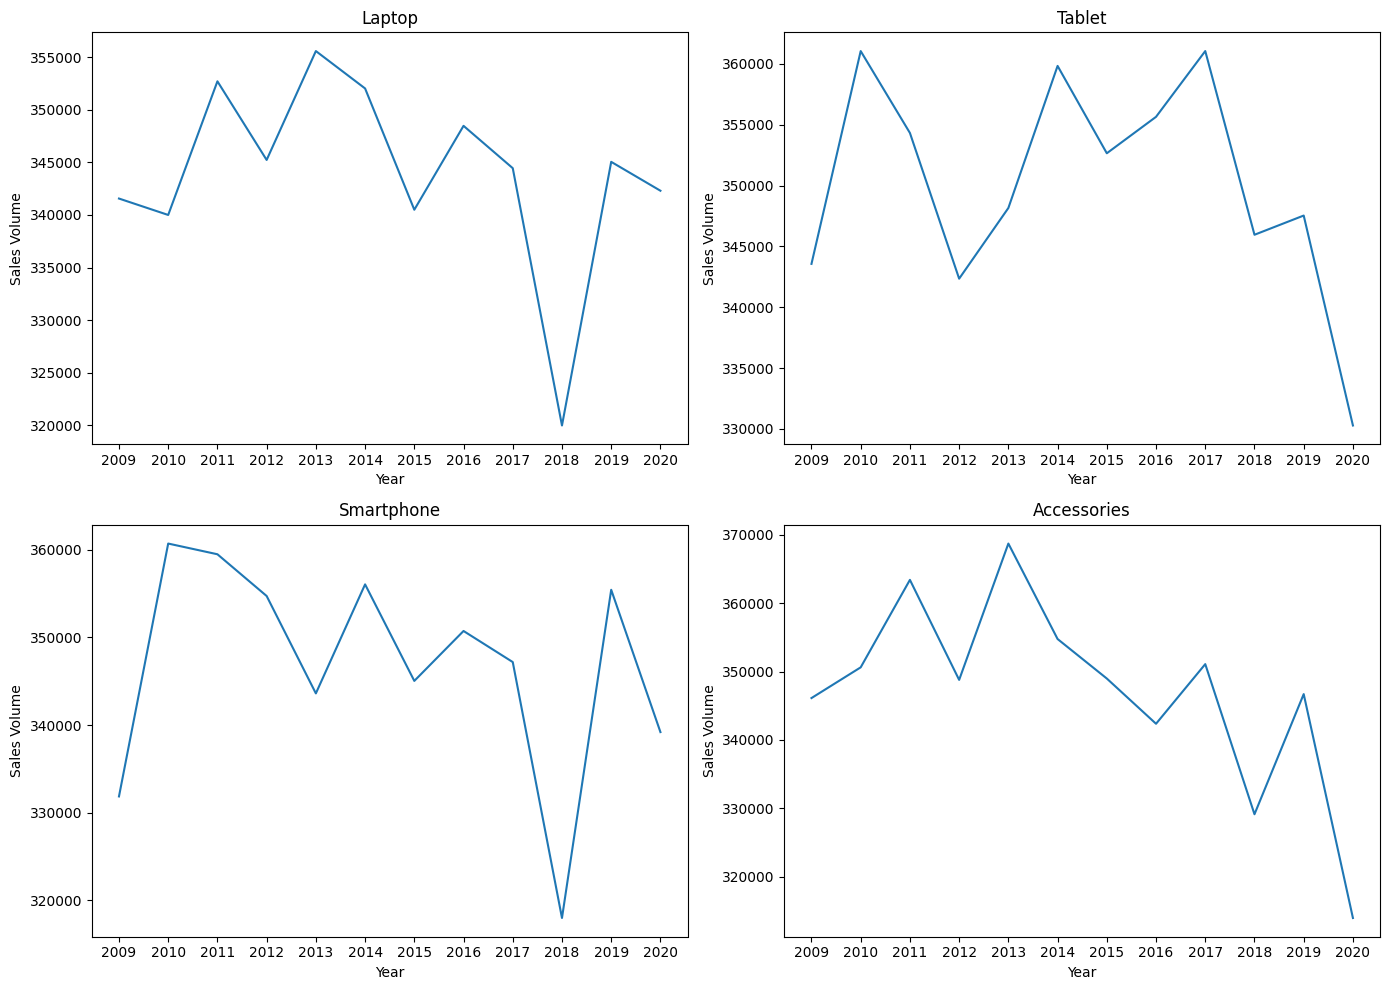

In [12]:
categories = data['Category'].unique().tolist() # Select up to 4 categories

plt.figure(figsize=(14, 10))

for i, category in enumerate(categories):
    subset = data[data['Category'] == category].copy()  # Avoid SettingWithCopyWarning
    subset['Year'] = pd.to_datetime(subset['Date']).dt.year
    
    # Aggregate Sales_Volume by Year
    yearly_summary = subset.groupby('Year')['Sales_Volume'].sum()
    
    # Create subplot
    plt.subplot(2, 2, i + 1)
    plt.plot(yearly_summary.index.astype(str), yearly_summary.values)
    plt.title(category)
    plt.xlabel('Year')
    plt.ylabel('Sales Volume')

plt.tight_layout()
plt.show()

In [13]:
data["YearMonth"]

0         2009-01
1         2009-01
2         2009-01
3         2009-01
4         2009-01
           ...   
136188    2020-12
136189    2020-12
136190    2020-12
136191    2020-12
136192    2020-12
Name: YearMonth, Length: 136193, dtype: period[M]

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136193 entries, 0 to 136192
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Product_ID                 136193 non-null  int64         
 1   Category                   136193 non-null  object        
 2   Price                      136193 non-null  float64       
 3   Date                       136193 non-null  datetime64[ns]
 4   Season                     136193 non-null  object        
 5   Market_Trend_Index         136193 non-null  float64       
 6   Competitor_Activity_Score  136193 non-null  float64       
 7   Consumer_Confidence_Index  136193 non-null  float64       
 8   Product_Specification_1    136193 non-null  object        
 9   Product_Specification_2    136193 non-null  object        
 10  Sales_Volume               136193 non-null  int64         
 11  YearMonth                  136193 non-null  period[M

<Axes: xlabel='YearMonth', ylabel='Sales_Volume'>

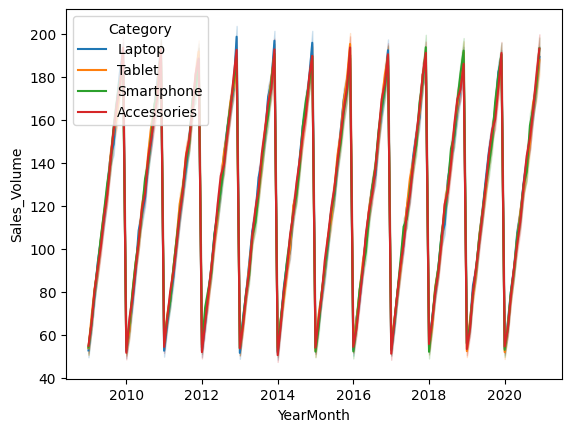

In [15]:
data['YearMonth'] = data['YearMonth'].dt.to_timestamp()

sns.lineplot(data=data, x='YearMonth', y='Sales_Volume', hue='Category')

In [16]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder


# OneHotEncoding for nominal columns (low cardinality)
ohe = OneHotEncoder(sparse_output=False)
# Specify your nominal column
col = 'Category'  # example

# Fit-transform the column
encoded_cols = ohe.fit_transform(data[[col]])

# Generate new column names
col_names = [f"{col}_{cat}" for cat in ohe.categories_[0]]

# Convert to DataFrame with original index for alignment
encoded_df = pd.DataFrame(encoded_cols, columns=col_names, index=data.index)

# Concatenate back to X
data = pd.concat([data, encoded_df], axis=1)

# Drop original column if no longer needed
data.drop(columns=col, inplace=True)

# To see encoded columns as DataFrame
#encoded_df = pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(['Category']))


# LabelEncoding for ordinal columns
le = LabelEncoder()


data['Season_encoded'] = le.fit_transform(data['Season'].astype(str))

In [17]:
data.describe(include="all")

,Product_ID,Price,Date,Season,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Product_Specification_1,Product_Specification_2,Sales_Volume,YearMonth,Category_Accessories,Category_Laptop,Category_Smartphone,Category_Tablet,Season_encoded
count,136193.000000,136193.000000,136193,136193,136193.000000,136193.000000,136193.000000,136193,136193,136193.000000,136193,136193.000000,136193.000000,136193.000000,136193.000000,136193.000000
unique,NaN,NaN,NaN,4,NaN,NaN,NaN,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Spring,NaN,NaN,NaN,Spec_C,Lightweight,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,34642,NaN,NaN,NaN,45652,45599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1347.703384,106.812513,2014-12-22 05:17:20.062264320,NaN,-0.000277,-0.000656,70.013109,NaN,NaN,122.305140,2014-12-07 12:29:37.888731392,0.249947,0.248192,0.249499,0.252362,1.497191
min,1001.000000,40.510000,2009-01-01 00:00:00,NaN,-4.067055,-4.181590,40.044830,NaN,NaN,6.000000,2009-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1174.000000,75.560000,2011-12-29 00:00:00,NaN,-0.683015,-0.676466,57.521063,NaN,NaN,81.000000,2011-12-01 00:00:00,0.000000,0.000000,0.000000,0.000000,1.000000
50%,1348.000000,104.710000,2014-12-19 00:00:00,NaN,0.001093,0.000555,70.022715,NaN,NaN,119.000000,2014-12-01 00:00:00,0.000000,0.000000,0.000000,0.000000,1.000000
75%,1522.000000,138.310000,2017-11-27 00:00:00,NaN,0.680506,0.674953,82.569582,NaN,NaN,161.000000,2017-11-01 00:00:00,0.000000,0.000000,0.000000,1.000000,2.000000
max,1694.000000,181.800000,2020-12-30 00:00:00,NaN,4.728391,4.661979,99.926291,NaN,NaN,306.000000,2020-12-01 00:00:00,1.000000,1.000000,1.000000,1.000000,3.000000


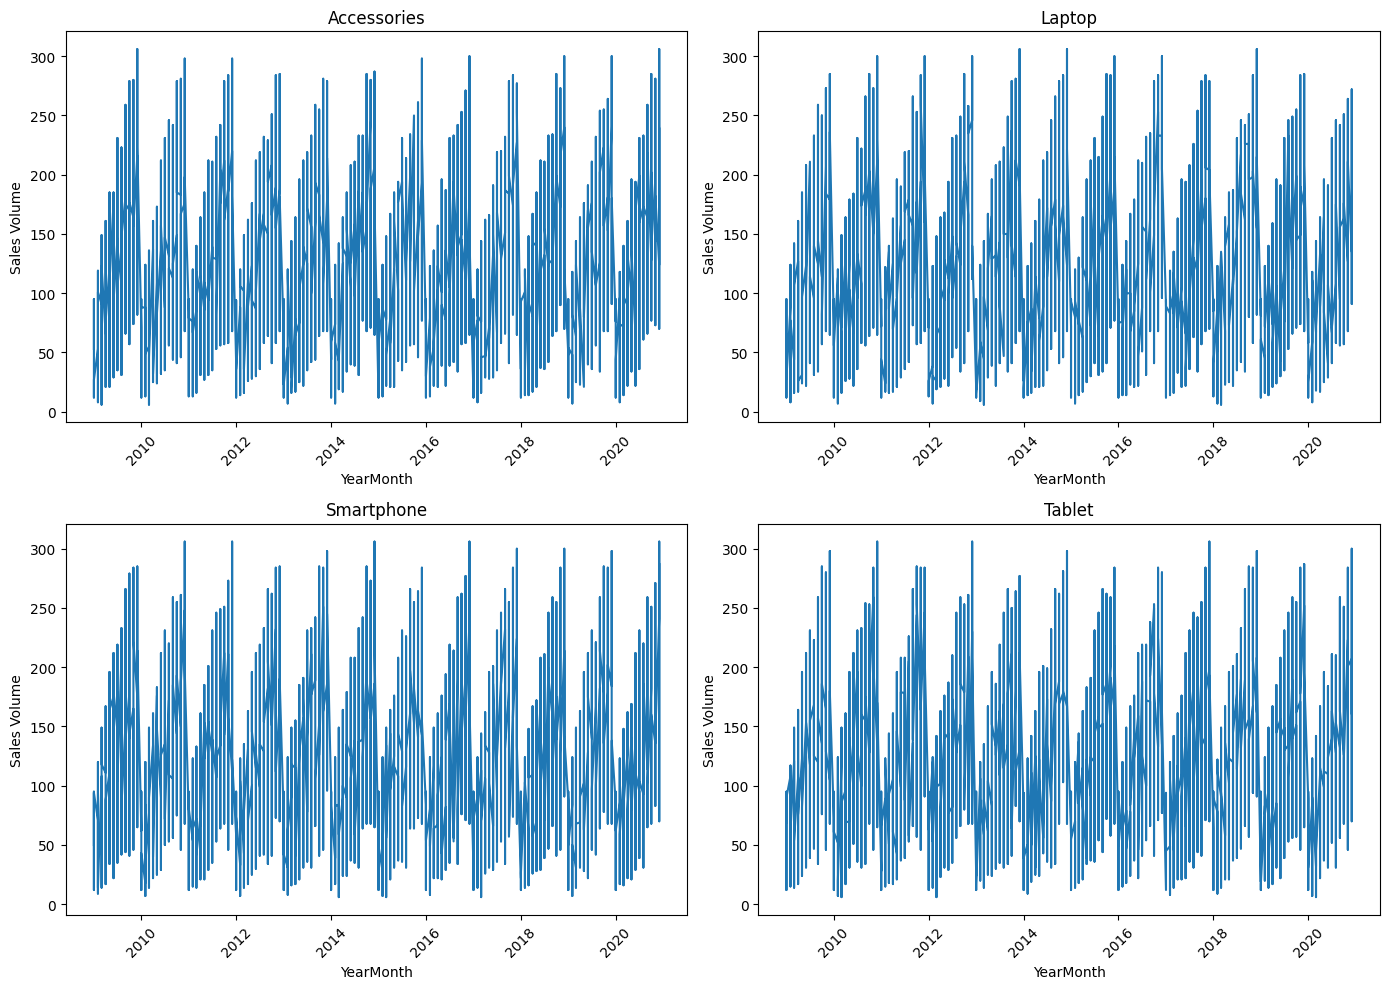

In [18]:
# Convert YearMonth to datetime if needed
data['YearMonth'] = pd.to_datetime(data['YearMonth'])

# Identify encoded category columns
category_cols = ['Category_Accessories', 'Category_Laptop', 'Category_Smartphone', 'Category_Tablet']

# Set up subplot grid: 2x2 for 4 categories
plt.figure(figsize=(14, 10))

for i, col in enumerate(category_cols):
    subset = data[data[col] == 1]
    
    plt.subplot(2, 2, i + 1)
    plt.plot(subset['YearMonth'], subset['Sales_Volume'])
    
    # Set title without 'Category_' prefix
    plt.title(col.replace('Category_', ''))
    
    plt.xlabel('YearMonth')
    plt.ylabel('Sales Volume')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [19]:
# Assuming your 'Date' or 'YearMonth' is already datetime
data['Month'] = pd.to_datetime(data['YearMonth']).dt.month_name()

In [20]:
data

,Product_ID,Price,Date,Season,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Product_Specification_1,Product_Specification_2,Sales_Volume,YearMonth,Category_Accessories,Category_Laptop,Category_Smartphone,Category_Tablet,Season_encoded,Month
0,1103,105.32,2009-01-01,Winter,-1.859160,0.546694,84.680465,Spec_C,Long-Battery-Life,49,2009-01-01,0.0,1.0,0.0,0.0,3,January
1,1436,145.55,2009-01-01,Winter,-0.345587,0.940428,42.919288,Spec_C,Lightweight,69,2009-01-01,0.0,0.0,0.0,1.0,3,January
2,1271,97.82,2009-01-01,Winter,-0.384738,0.751155,55.191268,Spec_B,Lightweight,50,2009-01-01,0.0,0.0,1.0,0.0,3,January
3,1107,64.00,2009-01-01,Winter,0.716763,0.125939,88.746454,Spec_B,High-Resolution,28,2009-01-01,0.0,1.0,0.0,0.0,3,January
4,1072,67.83,2009-01-01,Winter,-0.242074,-0.412932,67.947536,Spec_A,Long-Battery-Life,81,2009-01-01,0.0,0.0,0.0,1.0,3,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136188,1361,97.73,2020-12-29,Winter,0.953956,-0.555596,69.407099,Spec_C,High-Resolution,162,2020-12-01,0.0,0.0,0.0,1.0,3,December
136189,1147,173.21,2020-12-29,Winter,-0.781121,0.323828,90.737931,Spec_B,Long-Battery-Life,161,2020-12-01,0.0,0.0,0.0,1.0,3,December
136190,1405,154.62,2020-12-30,Winter,-0.210343,-1.055551,53.747320,Spec_A,Long-Battery-Life,182,2020-12-01,1.0,0.0,0.0,0.0,3,December
136191,1329,152.00,2020-12-30,Winter,-0.492417,-1.064359,88.582224,Spec_A,Long-Battery-Life,287,2020-12-01,0.0,0.0,1.0,0.0,3,December


In [21]:
monthly_sales = data.groupby('Month')['Sales_Volume'].sum()

In [22]:
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

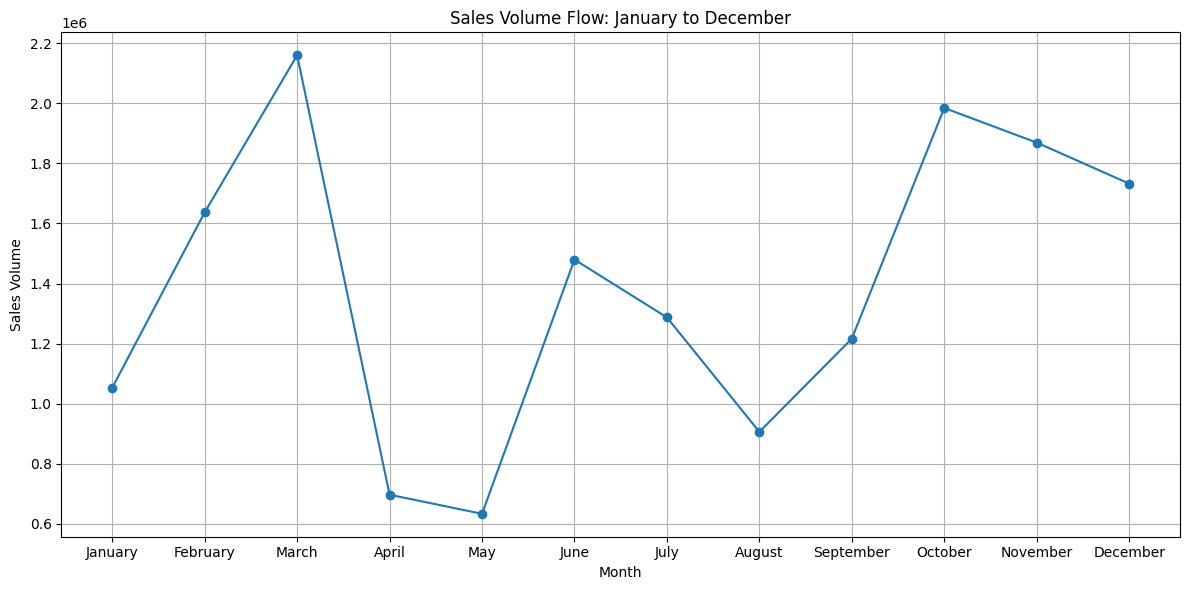

In [23]:
plt.figure(figsize=(12,6))
plt.plot(months_order, monthly_sales.values, marker='o')
plt.title('Sales Volume Flow: January to December')
plt.xlabel('Month')
plt.ylabel('Sales Volume')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
data['Month_num'] = data['YearMonth'].dt.month
data['Year'] = data['YearMonth'].dt.year

In [25]:
grouped = data.groupby(['Year', 'Month_num', 'Month'])['Sales_Volume'].sum().reset_index()

In [33]:
pivot = grouped.pivot_table(index=['Month_num', 'Month'], columns='Year', values='Sales_Volume')
pivot = pivot.sort_index().reset_index()

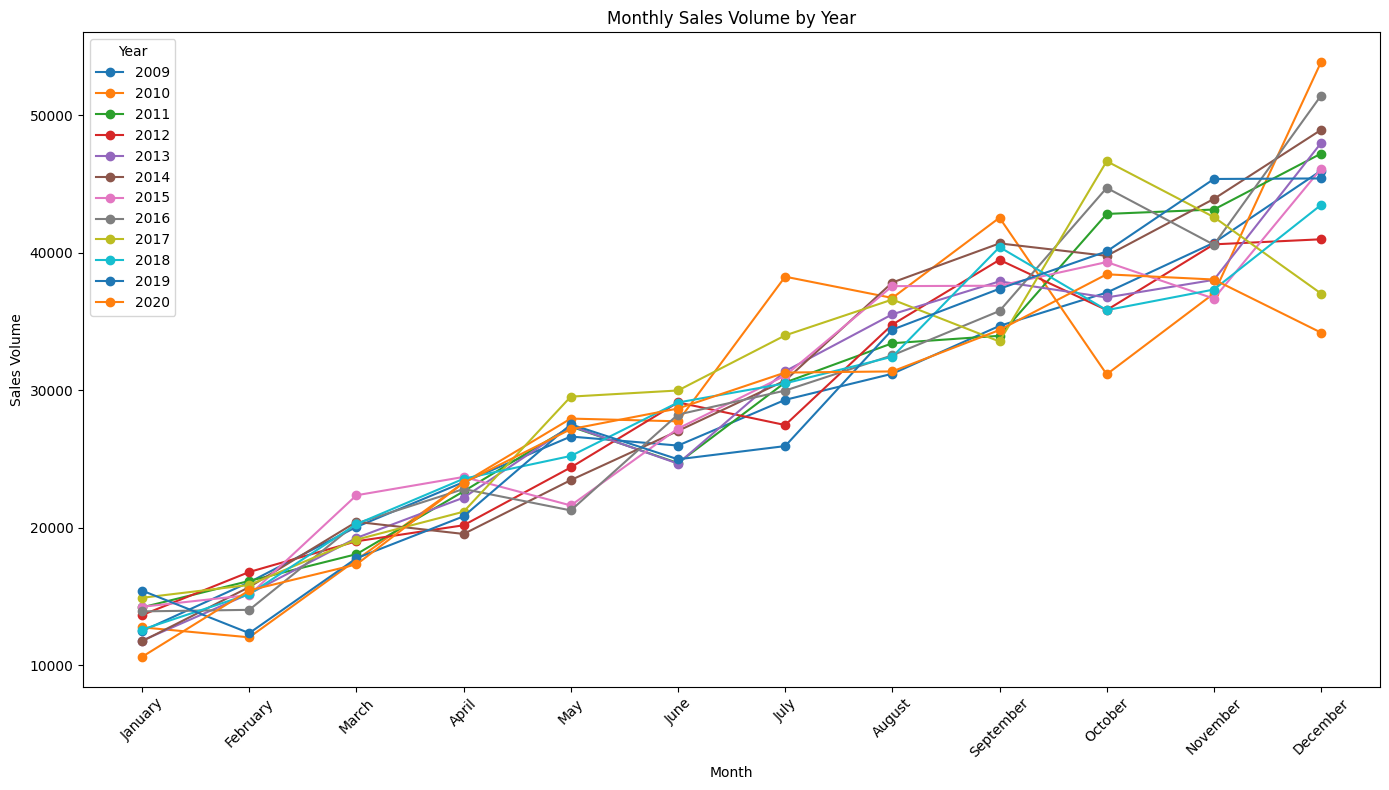

In [34]:
plt.figure(figsize=(14,8))

for year in pivot.columns[2:]:  # skip Month_num and Month columns
    plt.plot(pivot['Month'], pivot[year], marker='o', label=year)

plt.title('Monthly Sales Volume by Year')
plt.xlabel('Month')
plt.ylabel('Sales Volume')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

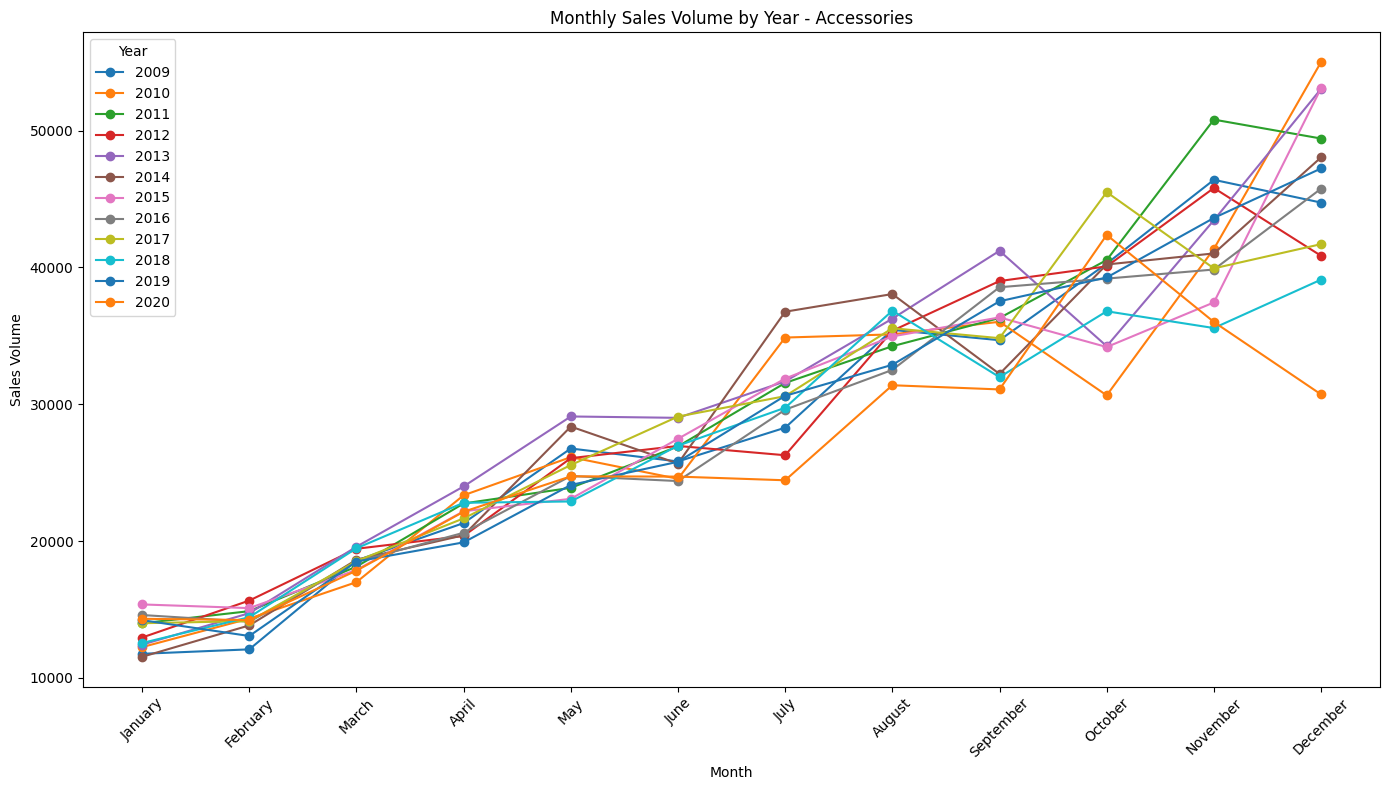

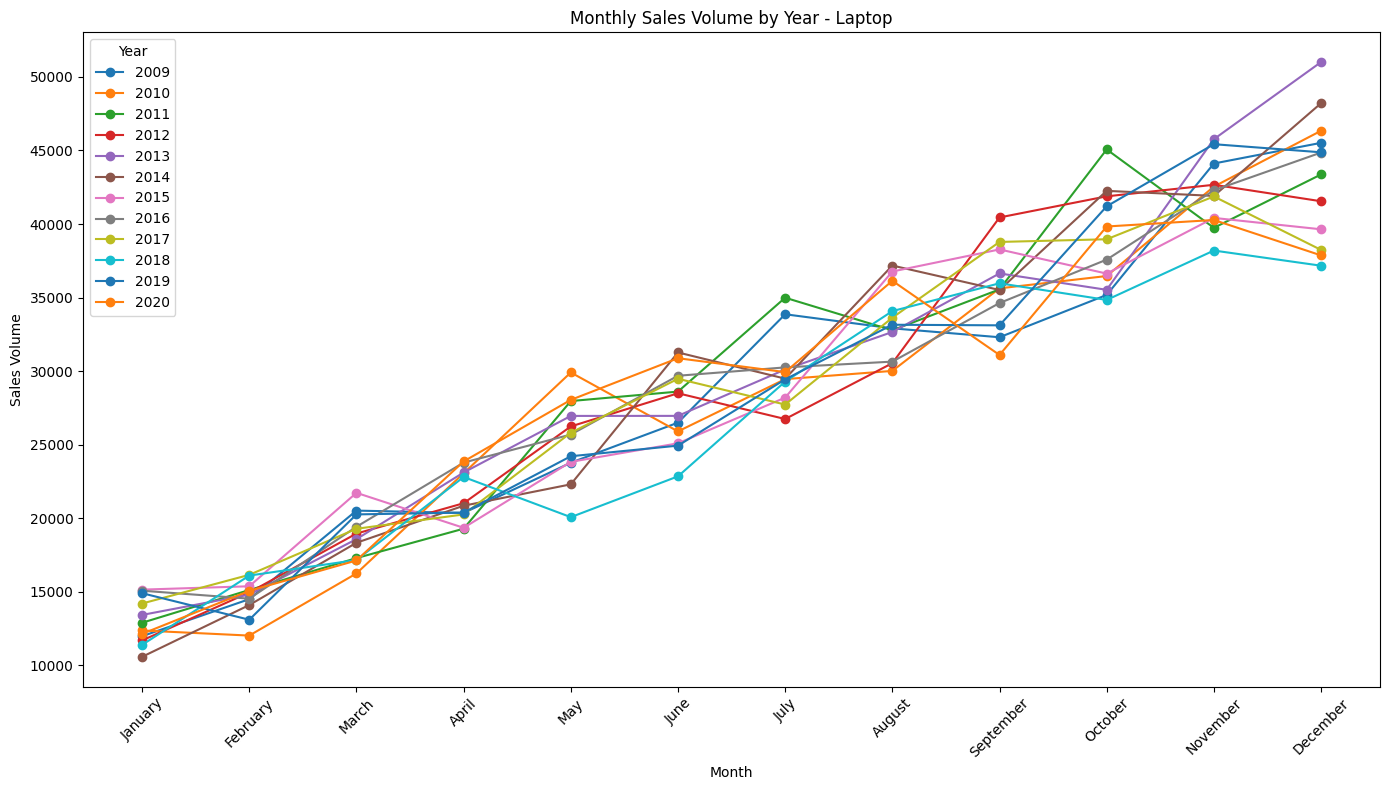

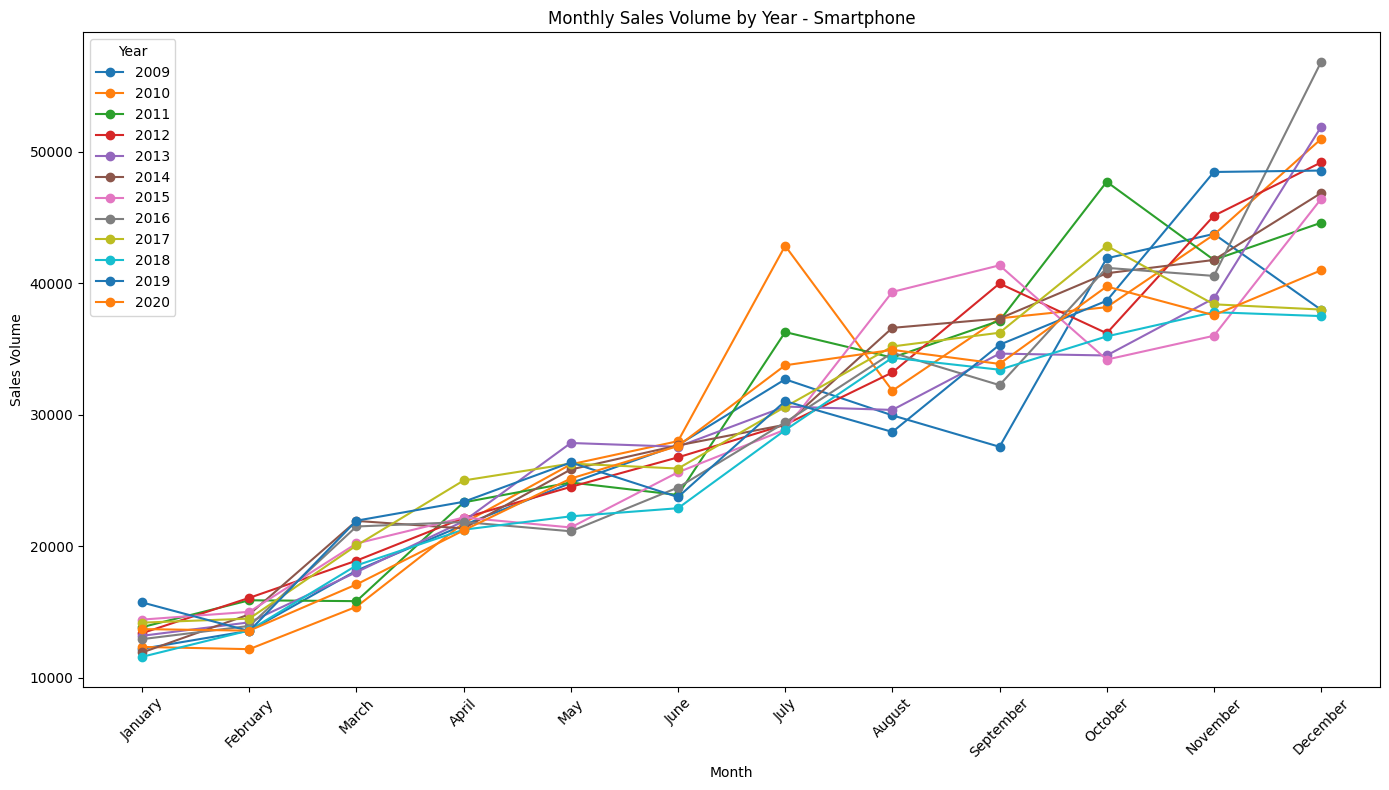

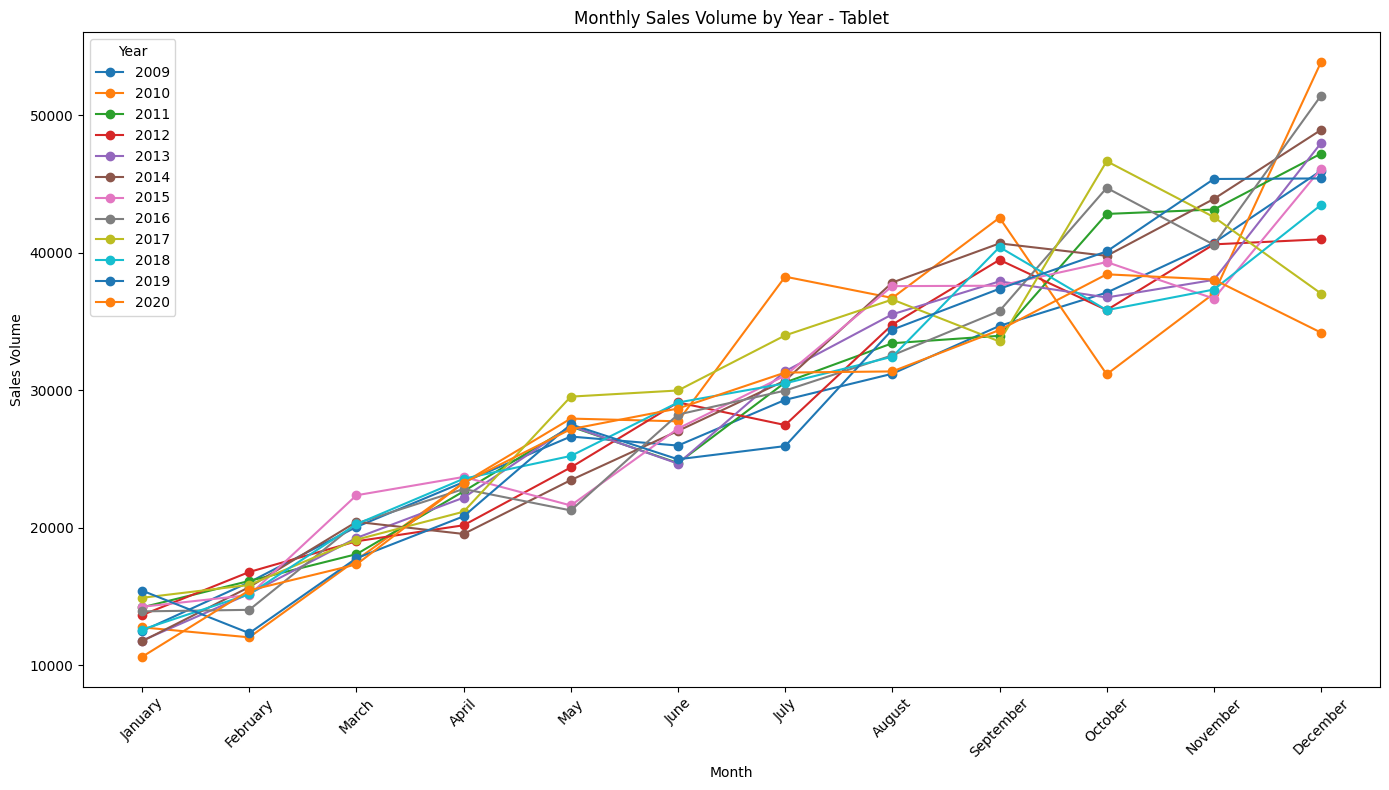

In [28]:
category_cols = ['Category_Accessories', 'Category_Laptop', 'Category_Smartphone', 'Category_Tablet']

for cat_col in category_cols:
    # Filter data for this category
    subset = data[data[cat_col] == 1]

    # Group by Year, Month_num, and Month to get monthly sales sum
    grouped = subset.groupby(['Year', 'Month_num', 'Month'])['Sales_Volume'].sum().reset_index()

    # Pivot table: index is Month_num & Month, columns are Years, values are Sales_Volume
    pivot = grouped.pivot_table(index=['Month_num', 'Month'], columns='Year', values='Sales_Volume')
    pivot = pivot.sort_index().reset_index()

    # Plot monthly sales by year for this category
    plt.figure(figsize=(14, 8))
    for year in pivot.columns[2:]:  # skip Month_num and Month columns
        plt.plot(pivot['Month'], pivot[year], marker='o', label=str(year))

    plt.title(f'Monthly Sales Volume by Year - {cat_col.replace("Category_", "")}')
    plt.xlabel('Month')
    plt.ylabel('Sales Volume')
    plt.xticks(rotation=45)
    plt.legend(title='Year')
    plt.tight_layout()
    plt.show()


Correlation Matrix:
                              Price  Market_Trend_Index  \
Price                      1.000000           -0.001293   
Market_Trend_Index        -0.001293            1.000000   
Competitor_Activity_Score -0.001256           -0.002643   
Consumer_Confidence_Index  0.002414           -0.001214   
Sales_Volume               0.092713           -0.001817   
Season_encoded            -0.030253           -0.002537   
Category_Accessories      -0.001864            0.001552   
Category_Laptop           -0.002416           -0.000299   
Category_Smartphone        0.003061           -0.002706   
Category_Tablet            0.001212            0.001445   

                           Competitor_Activity_Score  \
Price                                      -0.001256   
Market_Trend_Index                         -0.002643   
Competitor_Activity_Score                   1.000000   
Consumer_Confidence_Index                   0.002260   
Sales_Volume                               -0.0012

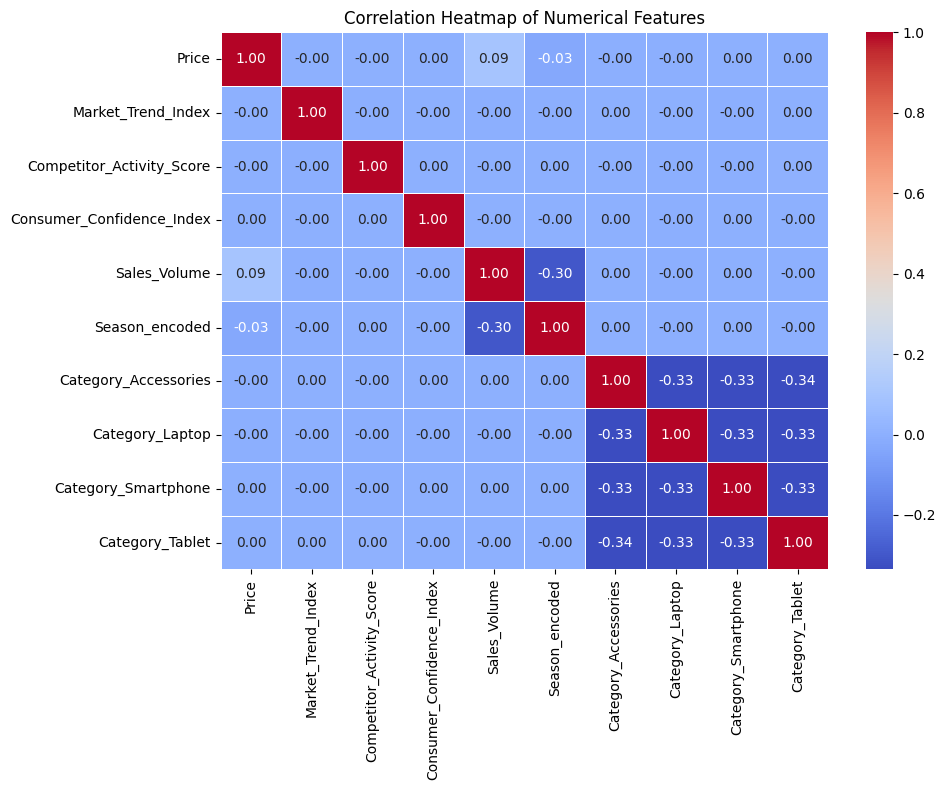

In [29]:
# Select numerical columns for correlation
numerical_cols = [
    'Price',
    'Market_Trend_Index',
    'Competitor_Activity_Score',
    'Consumer_Confidence_Index',
    'Sales_Volume',
    'Season_encoded',
    'Category_Accessories',
    'Category_Laptop',
    'Category_Smartphone',
    'Category_Tablet'
]

# Compute correlation matrix
corr_matrix = data[numerical_cols].corr()

# Display correlation matrix
print("Correlation Matrix:")
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()